In [ ]:
print("Setup and computation")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

import sys
sys.path.insert(0, str(Path('../../src').resolve()))
sys.path.insert(0, str(Path('..').resolve()))
from landscape import Landscape
from cgf import psi_1, psi_2
import style_config as sc

FIG2_DIR = Path("../fig2")

sqrt_eps_fit_lo = 0.2
sqrt_eps_fit_hi = 0.4
sqrt_eps_plot_lo = -0.02
sqrt_eps_plot_hi = 1.0

theta = np.load(FIG2_DIR / "theta_sim_L100_C4.npy")
L, C = theta.shape
land = Landscape(theta)
phi_max = land.F_max
phi_min = land.F_min
phi_mean = psi_1(theta, 0.0)
phi_std = np.sqrt(psi_2(theta, 0.0))
print(f"L={L}, C={C}, phi_max={phi_max:.1f}, phi_min={phi_min:.1f}, "
      f"phi_mean={phi_mean:.1f}, phi_std={phi_std:.1f}")

phi_grid = np.linspace(phi_min + 0.001 * (phi_max - phi_min),
                       phi_max - 0.00001 * (phi_max - phi_min), 5000)
rho_phi = np.array([land.density(p, method='saddlepoint') for p in phi_grid])
log_rho_phi = np.log(rho_phi)

def sigmoid(phi, s_phi, phi_half):
    return 1 / (1 + np.exp(-(phi - phi_half) / s_phi))

def sigmoid_deriv(phi, s_phi, phi_half):
    g = sigmoid(phi, s_phi, phi_half)
    return g * (1 - g) / s_phi

def compute_rho_g(phi_grid, log_rho_phi, s_phi, phi_half):
    F_grid = sigmoid(phi_grid, s_phi, phi_half)
    gprime = np.clip(sigmoid_deriv(phi_grid, s_phi, phi_half), 1e-300, None)
    log_rho_g = log_rho_phi - np.log(gprime)
    F_max_g = sigmoid(phi_max, s_phi, phi_half)
    F_min_g = sigmoid(phi_min, s_phi, phi_half)
    eps_F = (F_max_g - F_grid) / L
    return F_grid, log_rho_g, eps_F, F_max_g, F_min_g

eps_phi = (phi_max - phi_grid) / L
sqrt_eps_phi = np.sqrt(eps_phi)

fit_mask = (sqrt_eps_phi > sqrt_eps_fit_lo) & (sqrt_eps_phi < sqrt_eps_fit_hi)
x_fit = sqrt_eps_phi[fit_mask]
y_fit = log_rho_phi[fit_mask] / L

A_add = 0.0
B_add = np.mean(y_fit / x_fit)
near_peak_phi = (sqrt_eps_phi > 0) & (sqrt_eps_phi < sqrt_eps_plot_hi)
print(f"\n  Additive (A=0 fixed, sqrt_eps in [{sqrt_eps_fit_lo}, {sqrt_eps_fit_hi}]): "
      f"B={B_add:.4f}")

phi_half = phi_max - 4 * phi_std
tups = [(2.0*phi_std, r'$s_\phi = 2\sigma$', sc.COLOR_SIGMOID[0]),
        (1.0*phi_std, r'$s_\phi = \sigma$', sc.COLOR_SIGMOID[1]),
        (0.5*phi_std, r'$s_\phi = 0.5\sigma$', sc.COLOR_SIGMOID[2])]
s_phi_vals, labels, colors = zip(*tups)

print(f"\nphi_half = phi_max - 4*sigma = {phi_half:.1f}")
print(f"phi_max - phi_half = {phi_max - phi_half:.1f}")

results = []
for s, lab in zip(s_phi_vals, labels):
    F_grid, log_rho_g, eps_F, F_max_g, F_min_g = compute_rho_g(
        phi_grid, log_rho_phi, s, phi_half)
    eps_F_total = (F_max_g - F_min_g) / L
    fit_max = 0.3 * eps_F_total
    near_peak = (eps_F > 1e-8) & (eps_F < fit_max)
    gp = F_max_g * (1 - F_max_g) / s
    B_F = B_add / np.sqrt(gp)
    A_F = A_add - np.log(gp) / L
    print(f"  {lab}: s={s:.1f}, F_max={F_max_g:.4f}, g'={gp:.5f}, "
          f"A_F={A_F:.4f}, B_F={B_F:.4f}")
    results.append(dict(
        s=s, label=lab, F_grid=F_grid, log_rho_g=log_rho_g,
        eps_F=eps_F, F_max_g=F_max_g, near_peak=near_peak,
        fit_max=fit_max, gp=gp, A_F=A_F, B_F=B_F,
    ))

Figure 5: Scaling under global epistasis
  Panel (a): additive density vs phi
  Panel (b): additive near-peak scaling
  Panel (c): sigmoid nonlinearities
  Panel (d): near-peak scaling in F-space


Saved fig5.pdf and fig5.png


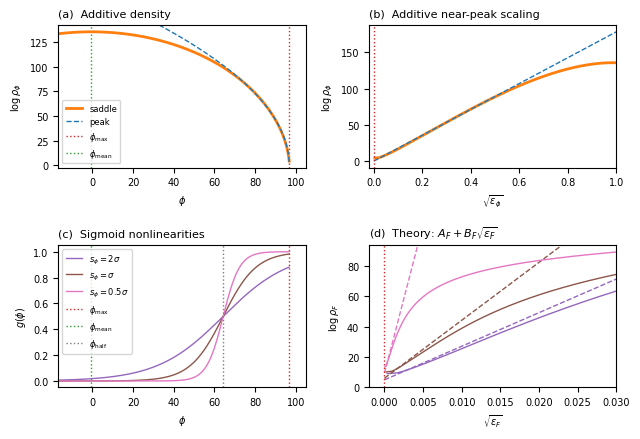

In [2]:
print("Figure 5: Scaling under global epistasis")

fig, axes = plt.subplots(2, 2, figsize=sc.FIGSIZE_2x2)
(ax_a, ax_b), (ax_c, ax_d) = axes

xlim_phi = (phi_mean - 2*phi_std, phi_max + phi_std)

print("  Panel (a): additive density vs phi")
ax_a.plot(phi_grid, log_rho_phi, **sc.STYLES["saddle"])
lr_pred_all = L * (A_add + B_add * np.sqrt((phi_max - phi_grid) / L))
ax_a.plot(phi_grid, lr_pred_all, **sc.STYLES["peak"])
ax_a.axvline(phi_max, **{**sc.STYLES["F_max"], "label": r"$\phi_\mathrm{max}$"})
ax_a.axvline(phi_mean, **{**sc.STYLES["F_mean"], "label": r"$\phi_\mathrm{mean}$"})
ax_a.set_xlabel(r'$\phi$')
ax_a.set_ylabel(r'$\log\rho_\phi$')
ax_a.set_title('(a)  Additive density', fontsize=sc.PANEL_TITLE_SIZE, loc='left')
ax_a.set_xlim(*xlim_phi)
ymin_a = log_rho_phi.min()
ymax_a = log_rho_phi.max()
ypad_a = 0.05 * (ymax_a - ymin_a)
ax_a.set_ylim(ymin_a - ypad_a, ymax_a + ypad_a)
ax_a.legend(**sc.LEGEND_KW, loc='lower left')

print("  Panel (b): additive near-peak scaling")
m_phi = near_peak_phi
ax_b.plot(sqrt_eps_phi[m_phi], log_rho_phi[m_phi], **{**sc.STYLES["saddle"], "label": None})
eps_fit_line = np.linspace(0, sqrt_eps_plot_hi, 200)
lr_fit_line = L * (A_add + B_add * eps_fit_line)
ax_b.plot(eps_fit_line, lr_fit_line, **{**sc.STYLES["peak"], "label": None})
ax_b.axvline(0, color=sc.STYLES["F_max"]["color"], ls=sc.STYLES["F_max"]["ls"], lw=sc.STYLES["F_max"]["lw"])
ax_b.set_xlim(sqrt_eps_plot_lo, sqrt_eps_plot_hi)
ax_b.set_xlabel(r'$\sqrt{\varepsilon_\phi}$')
ax_b.set_ylabel(r'$\log\rho_\phi$')
ax_b.set_title('(b)  Additive near-peak scaling', fontsize=sc.PANEL_TITLE_SIZE, loc='left')

print("  Panel (c): sigmoid nonlinearities")
for res, col in zip(results, colors):
    ax_c.plot(phi_grid, sigmoid(phi_grid, res['s'], phi_half),
              color=col, lw=1, label=res['label'])
ax_c.axvline(phi_max, **{**sc.STYLES["F_max"], "label": r"$\phi_\mathrm{max}$"})
ax_c.axvline(phi_mean, **{**sc.STYLES["F_mean"], "label": r"$\phi_\mathrm{mean}$"})
ax_c.axvline(phi_half, **sc.STYLES["phi_half"])
ax_c.set_xlabel(r'$\phi$')
ax_c.set_ylabel(r'$g(\phi)$')
ax_c.set_title('(c)  Sigmoid nonlinearities', fontsize=sc.PANEL_TITLE_SIZE, loc='left')
ax_c.legend(**sc.LEGEND_KW, loc='upper left')
ax_c.set_xlim(*xlim_phi)

print("  Panel (d): near-peak scaling in F-space")
ymax = -np.inf
for res, col in zip(results, colors):
    sqrt_eps = np.sqrt(res['eps_F'])
    m = (sqrt_eps > 0) & (sqrt_eps < 0.03) & np.isfinite(res['log_rho_g'])
    eps = res['eps_F'][m]
    lr = res['log_rho_g'][m]
    ax_d.plot(np.sqrt(eps), lr, color=col, lw=1)
    ymax = max(ymax, lr.max())
    eps_fit = np.linspace(0, 0.03**2, 200)
    lr_theory = L * (res['A_F'] + res['B_F'] * np.sqrt(eps_fit))
    ax_d.plot(np.sqrt(eps_fit), lr_theory, color=col, ls='--', lw=1)

ax_d.axvline(0, color=sc.STYLES["F_max"]["color"], ls=sc.STYLES["F_max"]["ls"], lw=sc.STYLES["F_max"]["lw"])
ypad = 0.05 * ymax
ax_d.set_ylim(0, ymax + ypad)
ax_d.set_xlim(-0.002, 0.03)
ax_d.set_xlabel(r'$\sqrt{\varepsilon_F}$')
ax_d.set_ylabel(r'$\log\rho_F$')
ax_d.set_title(r'(d)  Theory: $A_F + B_F\sqrt{\varepsilon_F}$', fontsize=sc.PANEL_TITLE_SIZE, loc='left')

fig.tight_layout()
fig.savefig('fig5.pdf', bbox_inches='tight')
fig.savefig('fig5.png', dpi=300, bbox_inches='tight')
print("Saved fig5.pdf and fig5.png")
plt.show()